# **Deteksi Tingkat Kematangan Buah Kelapa Sawit dari Citra Tandan Menggunakan Convolutional Neural Network dengan Pendekatan Transfer Learning**

**Kelompok 10 - Kelas 2024E**
- Lailil Hidayanti (24031554036)
- Rahmawati Dian Pratiwi (24031554183)
- Nurlaila Lutfi Azizah (24051554205)

---

### Pipeline
```
1. Setup & Instalasi
2. Load Dataset (Roboflow)
3. Exploratory Data Analysis (EDA)
4. Preprocessing & DataLoader
5. Handling Class Imbalance
6. Transfer Learning (EfficientNetV2-S + Custom Head)
7. Two-Phase Fine-Tuning
   Phase 1: Feature Extraction (backbone frozen)
   Phase 2: Fine-Tuning (backbone unfrozen)
8. Evaluasi (Accuracy, F1, Confusion Matrix, Cohen's Kappa)
9. Grad-CAM Visualization (Interactive)
10. Baseline Model: SVM + Fitur Pretrained CNN (Hybrid)
    10.1 Ekstraksi Fitur menggunakan EfficientNetV2-S (Frozen)
    10.2 Training SVM Classifier
    10.3 Evaluasi SVM pada Test Set
    10.4 Perbandingan EfficientNetV2-S vs SVM Baseline
```

## **1. Setup & Instalasi**

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm

from sklearn.metrics import (
    classification_report, confusion_matrix,
    cohen_kappa_score, accuracy_score, f1_score
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## **2. Load Dataset dari Roboflow**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR  = Path("/content/drive/MyDrive/Dataset_Kelapa_Sawit_Fixed")
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'valid'
TEST_DIR  = DATA_DIR / 'test'

# Verifikasi
assert TRAIN_DIR.exists(), f"Train dir tidak ditemukan: {TRAIN_DIR}"
assert VAL_DIR.exists(),   f"Valid dir tidak ditemukan: {VAL_DIR}"
assert TEST_DIR.exists(),  f"Test  dir tidak ditemukan: {TEST_DIR}"

print(f'Dataset location : {DATA_DIR.resolve()}')
print(f'Train dir exists : {TRAIN_DIR.exists()}')
print(f'Valid dir exists : {VAL_DIR.exists()}')
print(f'Test  dir exists : {TEST_DIR.exists()}')

Dataset location : /content/drive/.shortcut-targets-by-id/1Ay8AcsPqgCoCeY3Ie-ltee7kqpfPbM1a/Dataset_Kelapa_Sawit_Fixed
Train dir exists : True
Valid dir exists : True
Test  dir exists : True


In [ ]:
# Inventarisasi jumlah sampel per kelas per split
CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(f'Kelas ({NUM_CLASSES}): {CLASS_NAMES}')

def count_per_class(split_dir):
    return {cls: len(list((split_dir / cls).glob('*.[jp][pn]g')) +
                      list((split_dir / cls).glob('*.jpeg')))
            for cls in CLASS_NAMES}

train_counts = count_per_class(TRAIN_DIR)
val_counts   = count_per_class(VAL_DIR)
test_counts  = count_per_class(TEST_DIR)

print('\n{:<15} {:>8} {:>8} {:>8}'.format('Kelas', 'Train', 'Valid', 'Test'))
print('-' * 43)
for cls in CLASS_NAMES:
    print(f'{cls:<15} {train_counts[cls]:>8} {val_counts[cls]:>8} {test_counts[cls]:>8}')
print('-' * 43)
print(f'{"TOTAL":<15} {sum(train_counts.values()):>8} {sum(val_counts.values()):>8} {sum(test_counts.values()):>8}')

Kelas (6): ['empty_bunch', 'overripe', 'ripe', 'rotten', 'underripe', 'unripe']

Kelas              Train    Valid     Test
-------------------------------------------
empty_bunch          168       24       32
overripe             298       62       63
ripe                 797      180      169
rotten                51        6       29
underripe            679      170      139
unripe               106       28       23
-------------------------------------------
TOTAL               2099      470      455


## **3. Exploratory Data Analysis (EDA)**

### 3.1 Distribusi Dataset (Bar + Pie)

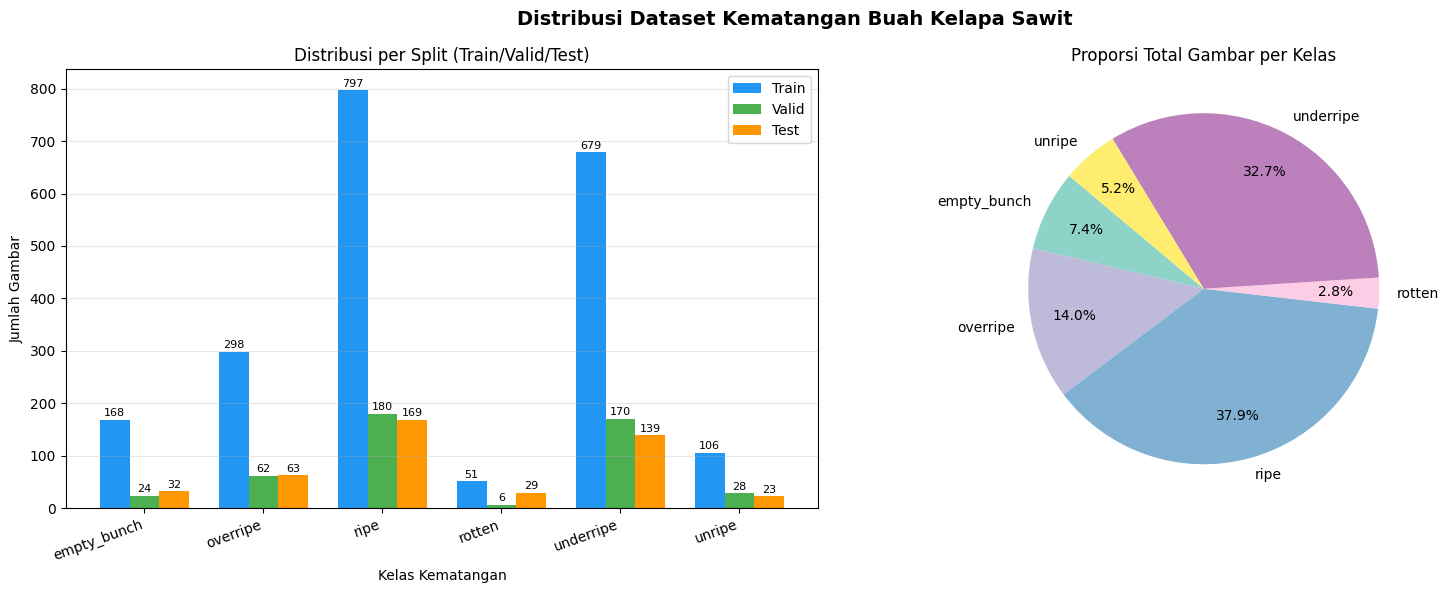

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribusi Dataset Kematangan Buah Kelapa Sawit', fontsize=14, fontweight='bold')

x = np.arange(len(CLASS_NAMES))
width = 0.25
colors = ['#2196F3', '#4CAF50', '#FF9800']

ax = axes[0]
bars1 = ax.bar(x - width, [train_counts[c] for c in CLASS_NAMES], width, label='Train', color=colors[0])
bars2 = ax.bar(x,         [val_counts[c]   for c in CLASS_NAMES], width, label='Valid', color=colors[1])
bars3 = ax.bar(x + width, [test_counts[c]  for c in CLASS_NAMES], width, label='Test',  color=colors[2])

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 3, str(int(h)),
                    ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Kelas Kematangan')
ax.set_ylabel('Jumlah Gambar')
ax.set_title('Distribusi per Split (Train/Valid/Test)')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Pie chart total
total_counts = {cls: train_counts[cls] + val_counts[cls] + test_counts[cls] for cls in CLASS_NAMES}
total_values = [total_counts[c] for c in CLASS_NAMES]
pie_colors   = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))
wedges, texts, autotexts = axes[1].pie(
    total_values, labels=CLASS_NAMES, autopct='%1.1f%%',
    colors=pie_colors, startangle=140, pctdistance=0.75
)
axes[1].set_title('Proporsi Total Gambar per Kelas')

plt.tight_layout()
plt.savefig('eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Imbalanced Analysis (Horizontal Bar)

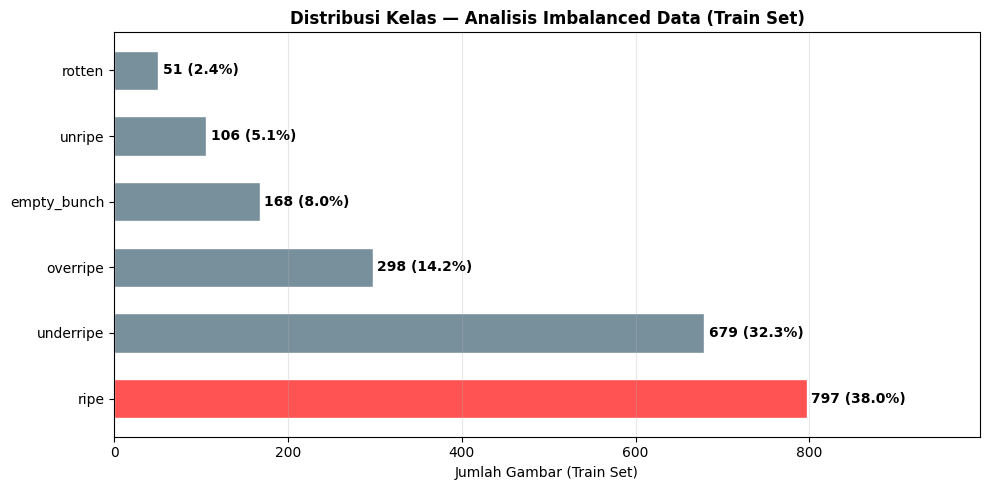


Imbalance Ratio (max/min): 15.6x
Kelas dominan  : ripe (797 sampel)
Kelas minoritas: rotten (51 sampel)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
total_train = sum(train_counts.values())
sorted_cls  = sorted(CLASS_NAMES, key=lambda c: train_counts[c], reverse=True)
vals        = [train_counts[c] for c in sorted_cls]
bar_colors  = ['#FF5252' if v == max(vals) else '#78909C' for v in vals]

bars = ax.barh(sorted_cls, vals, color=bar_colors, edgecolor='white', height=0.6)
for bar, v in zip(bars, vals):
    pct = v / total_train * 100
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{v} ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Jumlah Gambar (Train Set)')
ax.set_title('Distribusi Kelas — Analisis Imbalanced Data (Train Set)', fontweight='bold')
ax.set_xlim(0, max(vals) * 1.25)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance_ratio = max(vals) / min(vals)
print(f'\nImbalance Ratio (max/min): {imbalance_ratio:.1f}x')
print(f'Kelas dominan  : {sorted_cls[0]} ({vals[0]} sampel)')
print(f'Kelas minoritas: {sorted_cls[-1]} ({vals[-1]} sampel)')

### **3.3 Contoh Gambar per Kelas**

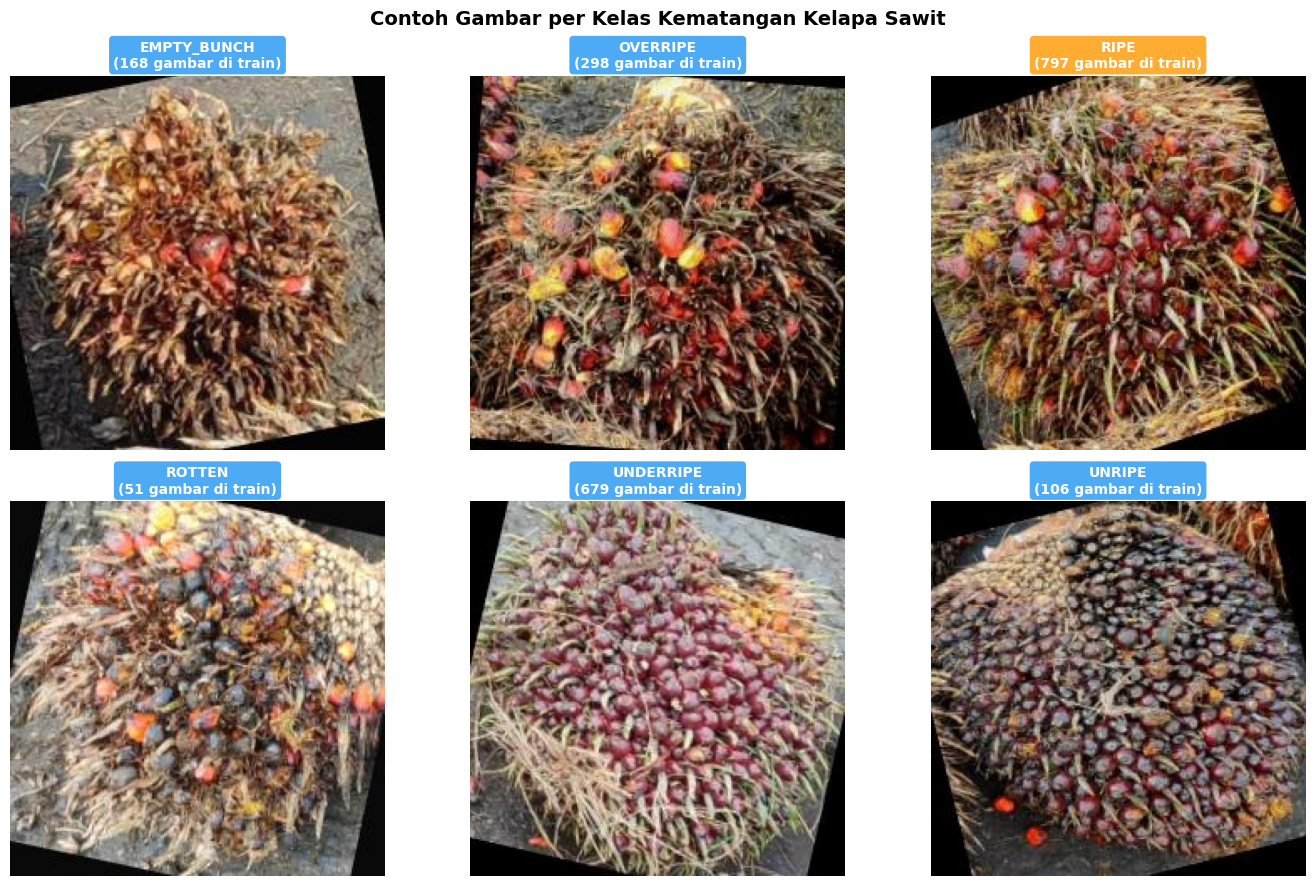

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Contoh Gambar per Kelas Kematangan Kelapa Sawit', fontsize=14, fontweight='bold')

for ax, cls in zip(axes.flat, CLASS_NAMES):
    imgs = list((TRAIN_DIR / cls).glob('*.[jp][pn]g')) + \
           list((TRAIN_DIR / cls).glob('*.jpeg'))
    if imgs:
        img = Image.open(random.choice(imgs)).convert('RGB')
        ax.imshow(img)
    ax.set_title(f'{cls.upper()}\n({train_counts[cls]} gambar di train)',
                 fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='#FF9800' if cls == 'ripe' else '#2196F3',
                           alpha=0.8, edgecolor='none'),
                 color='white')
    ax.axis('off')

plt.tight_layout()
plt.savefig('eda_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### **3.4 Analisis Ukuran Gambar**

Mengecek ukuran gambar (sample 20 per kelas)...
            width                                                height  \
            count   mean  std    min    25%    50%    75%    max  count   
class                                                                     
empty_bunch  20.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0   20.0   
overripe     20.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0   20.0   
ripe         20.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0   20.0   
rotten       20.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0   20.0   
underripe    20.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0   20.0   
unripe       20.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0   20.0   

                                                            
              mean  std    min    25%    50%    75%    max  
class                                                       
empty_bunch  640.0  0.0  640.0  640.0  640.0  640.0  640.0  
overripe     640.0  0.0  640.0  

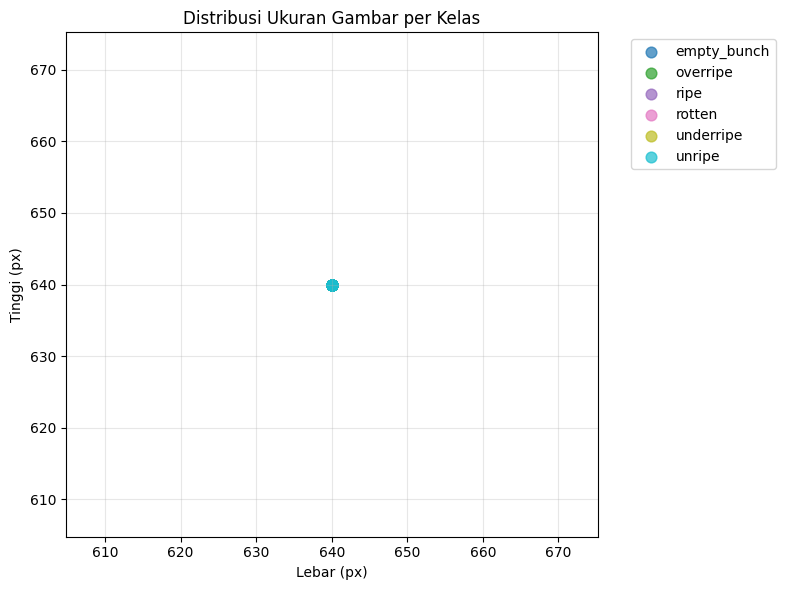

In [ ]:
print('Mengecek ukuran gambar (sample 20 per kelas)...')
size_data = []
for cls in CLASS_NAMES:
    imgs = (list((TRAIN_DIR / cls).glob('*.[jp][pn]g')) +
            list((TRAIN_DIR / cls).glob('*.jpeg')))[:20]
    for p in imgs:
        w, h = Image.open(p).size
        size_data.append({'class': cls, 'width': w, 'height': h})

import pandas as pd
df_size = pd.DataFrame(size_data)
print(df_size.groupby('class')[['width','height']].describe())

fig, ax = plt.subplots(figsize=(8, 6))
palette = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
for i, cls in enumerate(CLASS_NAMES):
    sub = df_size[df_size['class'] == cls]
    ax.scatter(sub['width'], sub['height'], label=cls, color=palette[i], alpha=0.7, s=60)
ax.set_xlabel('Lebar (px)')
ax.set_ylabel('Tinggi (px)')
ax.set_title('Distribusi Ukuran Gambar per Kelas')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('eda_image_size.png', dpi=150, bbox_inches='tight')
plt.show()

### **3.5 Analisis RGB per Kelas**

Menghitung rata-rata RGB per kelas (sample 30 per kelas)


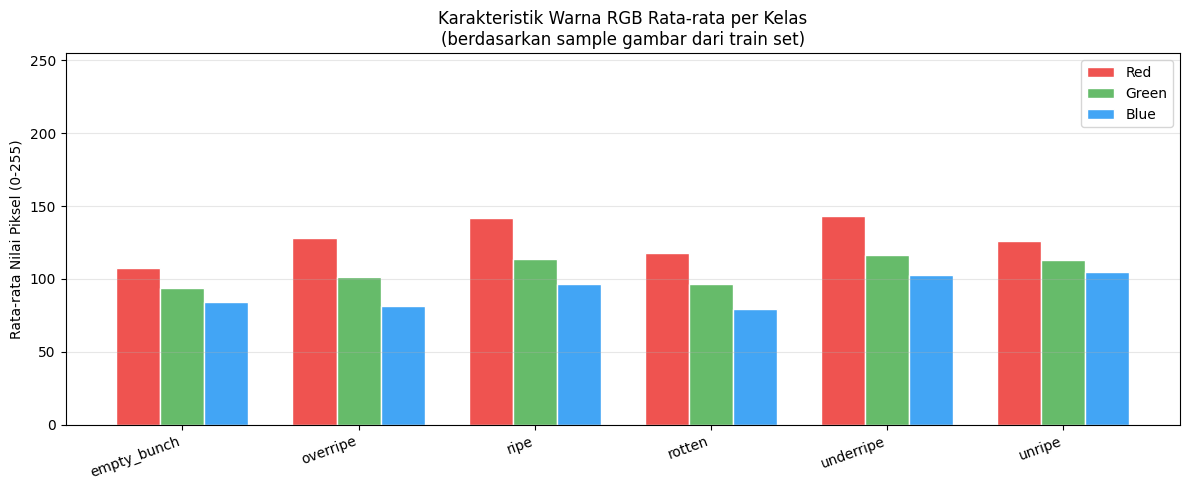

In [ ]:
print('Menghitung rata-rata RGB per kelas (sample 30 per kelas)')
rgb_stats = {}
for cls in CLASS_NAMES:
    imgs = (list((TRAIN_DIR / cls).glob('*.[jp][pn]g')) +
            list((TRAIN_DIR / cls).glob('*.jpeg')))[:30]
    r_vals, g_vals, b_vals = [], [], []
    for p in imgs:
        arr = np.array(Image.open(p).convert('RGB'), dtype=np.float32)
        r_vals.append(arr[:,:,0].mean())
        g_vals.append(arr[:,:,1].mean())
        b_vals.append(arr[:,:,2].mean())
    rgb_stats[cls] = (np.mean(r_vals), np.mean(g_vals), np.mean(b_vals))

fig, ax = plt.subplots(figsize=(12, 5))
x_pos   = np.arange(len(CLASS_NAMES))
w       = 0.25
ax.bar(x_pos - w, [rgb_stats[c][0] for c in CLASS_NAMES], w, label='Red',   color='#EF5350', edgecolor='white')
ax.bar(x_pos,     [rgb_stats[c][1] for c in CLASS_NAMES], w, label='Green', color='#66BB6A', edgecolor='white')
ax.bar(x_pos + w, [rgb_stats[c][2] for c in CLASS_NAMES], w, label='Blue',  color='#42A5F5', edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
ax.set_ylabel('Rata-rata Nilai Piksel (0-255)')
ax.set_title('Karakteristik Warna RGB Rata-rata per Kelas\n(berdasarkan sample gambar dari train set)')
ax.legend()
ax.set_ylim(0, 255)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_rgb.png', dpi=150, bbox_inches='tight')
plt.show()

## **4. Preprocessing & DataLoader**

In [ ]:
# Hyperparameter
IMG_SIZE    = 224
BATCH_SIZE  = 32

# ImageNet stats
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(str(TRAIN_DIR), transform=transform)
val_dataset   = datasets.ImageFolder(str(VAL_DIR),   transform=transform)
test_dataset  = datasets.ImageFolder(str(TEST_DIR),  transform=transform)

CLASS_NAMES = train_dataset.classes
print(f'Kelas: {CLASS_NAMES}')
print(f'Train: {len(train_dataset)} | Valid: {len(val_dataset)} | Test: {len(test_dataset)}')

Kelas: ['empty_bunch', 'overripe', 'ripe', 'rotten', 'underripe', 'unripe']
Train: 2099 | Valid: 470 | Test: 455


## **5. Handling Class Imbalance**

### 5.1 Hitung class weights (invers frekuensi)

In [ ]:
targets     = [s[1] for s in train_dataset.samples]
class_count = Counter(targets)
total_train = len(targets)

class_weights = torch.tensor(
    [total_train / (NUM_CLASSES * class_count[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float
).to(DEVICE)

print('Class weights:')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:<15}: {class_weights[i].item():.4f}  (n={class_count[i]})')

Class weights:
  empty_bunch    : 2.0823  (n=168)
  overripe       : 1.1739  (n=298)
  ripe           : 0.4389  (n=797)
  rotten         : 6.8595  (n=51)
  underripe      : 0.5152  (n=679)
  unripe         : 3.3003  (n=106)


### 5.2 DataLoaders

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train batches: 66 | Val batches: 15 | Test batches: 15


### 5.3 Focal Loss


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.1, reduction='mean'):
        super().__init__()
        self.alpha           = alpha
        self.gamma           = gamma
        self.label_smoothing = label_smoothing
        self.reduction       = reduction

    def forward(self, logits, targets):
        n_cls = logits.size(1)
        # Label smoothing
        with torch.no_grad():
            smooth_targets = torch.zeros_like(logits)
            smooth_targets.fill_(self.label_smoothing / (n_cls - 1))
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)

        log_probs = torch.log_softmax(logits, dim=1)
        probs     = torch.exp(log_probs)

        # (1 - pt)^gamma term
        pt      = (probs * smooth_targets).sum(dim=1)
        focal_w = (1 - pt) ** self.gamma

        # Cross-entropy with smooth targets
        ce_loss = -(smooth_targets * log_probs).sum(dim=1)
        loss    = focal_w * ce_loss

        # Class weights
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            loss    = alpha_t * loss

        return loss.mean() if self.reduction == 'mean' else loss.sum()

criterion = FocalLoss(alpha=class_weights, gamma=2.0, label_smoothing=0.1)
print('FocalLoss initialized ✓')

FocalLoss initialized ✓


## **6. Transfer Learning EfficientNetV2-S + Custom Head**

In [ ]:
class PalmRipenessModel(nn.Module):
    def __init__(self, num_classes=6, dropout=0.4):
        super().__init__()
        # Load backbone dengan timm (ImageNet-21k pretrained)
        self.backbone = timm.create_model(
            'tf_efficientnetv2_s.in21k',
            pretrained=True,
            num_classes=0,           # hapus classifier bawaan
            global_pool='avg'        # GlobalAvgPool
        )
        in_features = self.backbone.num_features

        # Custom classification head
        self.head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def freeze_backbone(self):
        """Phase 1: bekukan seluruh backbone"""
        for param in self.backbone.parameters():
            param.requires_grad = False

    def unfreeze_backbone(self):
        """Phase 2: buka semua lapisan"""
        for param in self.backbone.parameters():
            param.requires_grad = True

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)


model = PalmRipenessModel(num_classes=NUM_CLASSES).to(DEVICE)

# Ringkasan parameter
total_params   = sum(p.numel() for p in model.parameters())
trainable_head = sum(p.numel() for p in model.head.parameters())
print(f'Total params      : {total_params:,}')
print(f'Head params       : {trainable_head:,}')
print(f'Backbone params   : {total_params - trainable_head:,}')

model.safetensors:   0%|          | 0.00/193M [00:00<?, ?B/s]

Total params      : 20,507,478
Head params       : 329,990
Backbone params   : 20,177,488


## **7. Two-Phase Fine-Tuning**

In [ ]:
# Utility: training & validation loop
from tqdm.notebook import tqdm

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds      = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for imgs, labels in tqdm(loader, desc='  Valid', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, macro_f1, accuracy


def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    metrics = [
        ('train_loss', 'val_loss',     'Loss',      'Loss'),
        ('train_acc',  'val_acc',      'Accuracy',  'Accuracy'),
        (None,         'val_macro_f1', 'Macro F1',  'F1 Score'),
    ]
    for ax, (tr_key, vl_key, label, ylabel) in zip(axes, metrics):
        if tr_key:
            ax.plot(history[tr_key], label='Train', color='#2196F3', linewidth=2)
        ax.plot(history[vl_key], label='Valid', color='#FF5722', linewidth=2)
        ax.set_title(label)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'history_{title.replace(" ","_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Utility functions defined ✓')

Utility functions defined ✓


### **PHASE 1 Feature Extraction (backbone FROZEN)**

Phase 1 — Trainable params: 329,990 (head only)
PHASE 1: Feature Extraction


  Train:   0%|          | 0/66 [00:00<?, ?it/s]

  Valid:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [ 1/12] Train Loss: 1.1949 Acc: 0.1758 | Val Loss: 0.9853 Acc: 0.2787 F1: 0.2367  ✓ saved


  Train:   0%|          | 0/66 [00:00<?, ?it/s]

...

  Valid:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [11/12] Train Loss: 0.3910 Acc: 0.7003 | Val Loss: 0.4953 Acc: 0.6362 F1: 0.5990  ✓ saved


  Train:   0%|          | 0/66 [00:00<?, ?it/s]

  Valid:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [12/12] Train Loss: 0.3678 Acc: 0.7103 | Val Loss: 0.4718 Acc: 0.6404 F1: 0.6106  ✓ saved


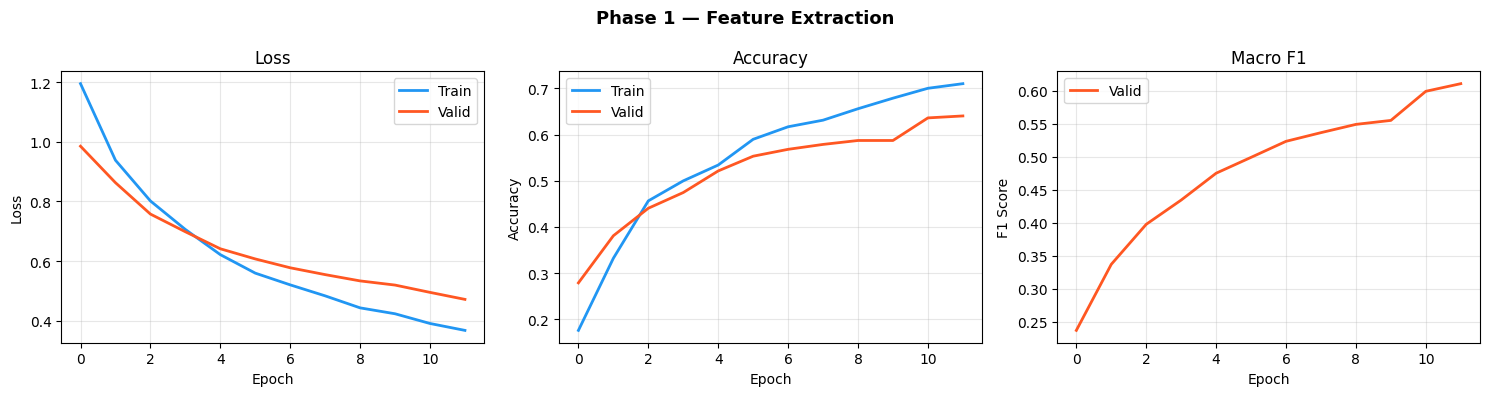


Best Val Macro F1 (Phase 1): 0.6106


In [ ]:
PHASE1_EPOCHS  = 12
PHASE1_LR      = 1e-3
PATIENCE       = 7
CHECKPOINT_P1  = 'best_phase1.pth'

model.freeze_backbone()
trainable_p1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 1 — Trainable params: {trainable_p1:,} (head only)')

optimizer_p1 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=PHASE1_LR, weight_decay=1e-4)
scheduler_p1 = optim.lr_scheduler.OneCycleLR(
    optimizer_p1, max_lr=PHASE1_LR,
    steps_per_epoch=len(train_loader), epochs=PHASE1_EPOCHS
)

history_p1  = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_macro_f1':[]}
best_f1_p1  = 0.0
patience_cnt = 0

print('PHASE 1: Feature Extraction')

for epoch in range(1, PHASE1_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer_p1, criterion, DEVICE)
    vl_loss, vl_f1, vl_acc = val_epoch(model, val_loader, criterion, DEVICE)
    scheduler_p1.step()

    history_p1['train_loss'].append(tr_loss)
    history_p1['train_acc'].append(tr_acc)
    history_p1['val_loss'].append(vl_loss)
    history_p1['val_acc'].append(vl_acc)
    history_p1['val_macro_f1'].append(vl_f1)

    flag = ''
    if vl_f1 > best_f1_p1:
        best_f1_p1  = vl_f1
        patience_cnt = 0
        torch.save(model.state_dict(), CHECKPOINT_P1)
        flag = '  ✓ saved'
    else:
        patience_cnt += 1

    print(f'Epoch [{epoch:2d}/{PHASE1_EPOCHS}] '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} F1: {vl_f1:.4f}{flag}')

    if patience_cnt >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

plot_history(history_p1, 'Phase 1 — Feature Extraction')
print(f'\nBest Val Macro F1 (Phase 1): {best_f1_p1:.4f}')

### PHASE 2 Fine-Tuning (ALL layers UNFROZEN)

Phase 2 — Trainable params: 20,507,478 (all layers)
PHASE 2: Fine-Tuning


  Train:   0%|          | 0/66 [00:00<?, ?it/s]

  Valid:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [ 1/40] Train Loss: 0.2870 Acc: 0.7608 | Val Loss: 0.2999 Acc: 0.7149 F1: 0.7393  ✓ saved


  Train:   0%|          | 0/66 [00:00<?, ?it/s]

...

  Valid:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [18/40] Train Loss: 0.0095 Acc: 1.0000 | Val Loss: 0.3964 Acc: 0.8319 F1: 0.8268


  Train:   0%|          | 0/66 [00:00<?, ?it/s]

  Valid:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [19/40] Train Loss: 0.0098 Acc: 0.9995 | Val Loss: 0.3683 Acc: 0.8340 F1: 0.8169
Early stopping at epoch 19


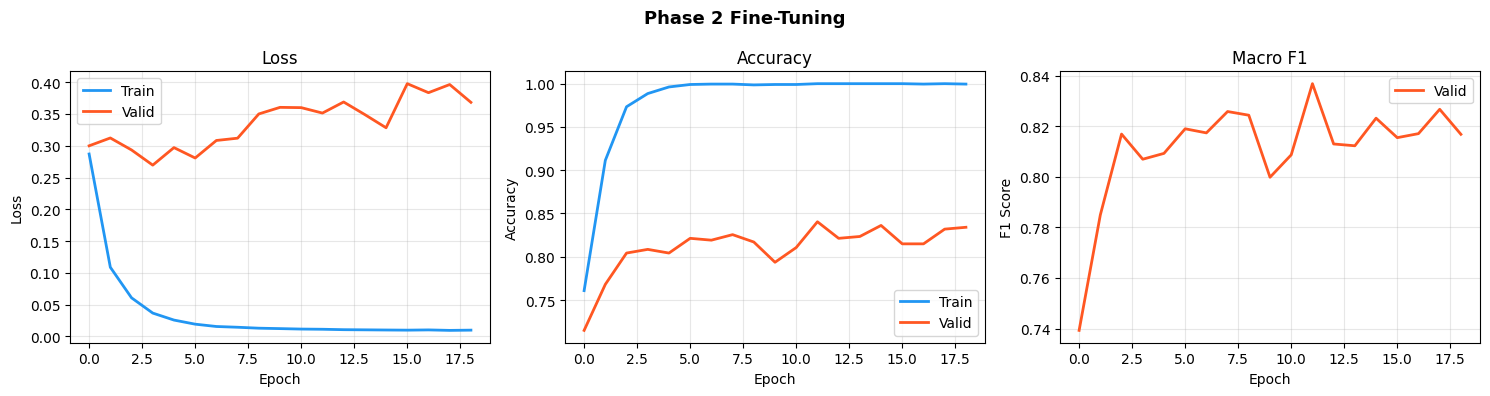


Best Val Macro F1 (Phase 2): 0.8370


In [ ]:
PHASE2_EPOCHS  = 40
PHASE2_LR      = 1e-4
CHECKPOINT_P2  = 'best_phase2.pth'

# Load best phase-1 weights sebelum fine-tuning
model.load_state_dict(torch.load(CHECKPOINT_P1, map_location=DEVICE))
model.unfreeze_backbone()
trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2 — Trainable params: {trainable_p2:,} (all layers)')

optimizer_p2 = optim.AdamW(model.parameters(), lr=PHASE2_LR, weight_decay=1e-4)
scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=PHASE2_EPOCHS, eta_min=1e-6
)

history_p2   = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_macro_f1':[]}
best_f1_p2   = 0.0
patience_cnt  = 0

print('PHASE 2: Fine-Tuning')
for epoch in range(1, PHASE2_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer_p2, criterion, DEVICE)
    vl_loss, vl_f1, vl_acc = val_epoch(model, val_loader, criterion, DEVICE)
    scheduler_p2.step()

    history_p2['train_loss'].append(tr_loss)
    history_p2['train_acc'].append(tr_acc)
    history_p2['val_loss'].append(vl_loss)
    history_p2['val_acc'].append(vl_acc)
    history_p2['val_macro_f1'].append(vl_f1)

    flag = ''
    if vl_f1 > best_f1_p2:
        best_f1_p2   = vl_f1
        patience_cnt  = 0
        torch.save(model.state_dict(), CHECKPOINT_P2)
        flag = '  ✓ saved'
    else:
        patience_cnt += 1

    print(f'Epoch [{epoch:2d}/{PHASE2_EPOCHS}] '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} F1: {vl_f1:.4f}{flag}')

    if patience_cnt >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

plot_history(history_p2, 'Phase 2 Fine-Tuning')
print(f'\nBest Val Macro F1 (Phase 2): {best_f1_p2:.4f}')

## **8. Evaluasi pada Test Set**

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT_P2, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Evaluating'):
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Metrik utama
acc      = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
micro_f1 = f1_score(all_labels, all_preds, average='micro',    zero_division=0)
kappa    = cohen_kappa_score(all_labels, all_preds)

print('=' * 55)
print('HASIL EVALUASI PADA TEST SET')
print('=' * 55)
print(f'  Accuracy       : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Macro F1-Score : {macro_f1:.4f}')
print(f'  Micro F1-Score : {micro_f1:.4f}')
print(f"  Cohen's Kappa  : {kappa:.4f}")
print('=' * 55)

print('\nClassification Report:')
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES,
                             zero_division=0))

Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]

HASIL EVALUASI PADA TEST SET
  Accuracy       : 0.8659  (86.59%)
  Macro F1-Score : 0.8260
  Micro F1-Score : 0.8659
  Cohen's Kappa  : 0.8178

Classification Report:
              precision    recall  f1-score   support

 empty_bunch       0.78      1.00      0.88        32
    overripe       0.98      0.98      0.98        63
        ripe       0.89      0.88      0.88       169
      rotten       1.00      0.52      0.68        29
   underripe       0.83      0.86      0.85       139
      unripe       0.67      0.70      0.68        23

    accuracy                           0.87       455
   macro avg       0.86      0.82      0.83       455
weighted avg       0.87      0.87      0.86       455



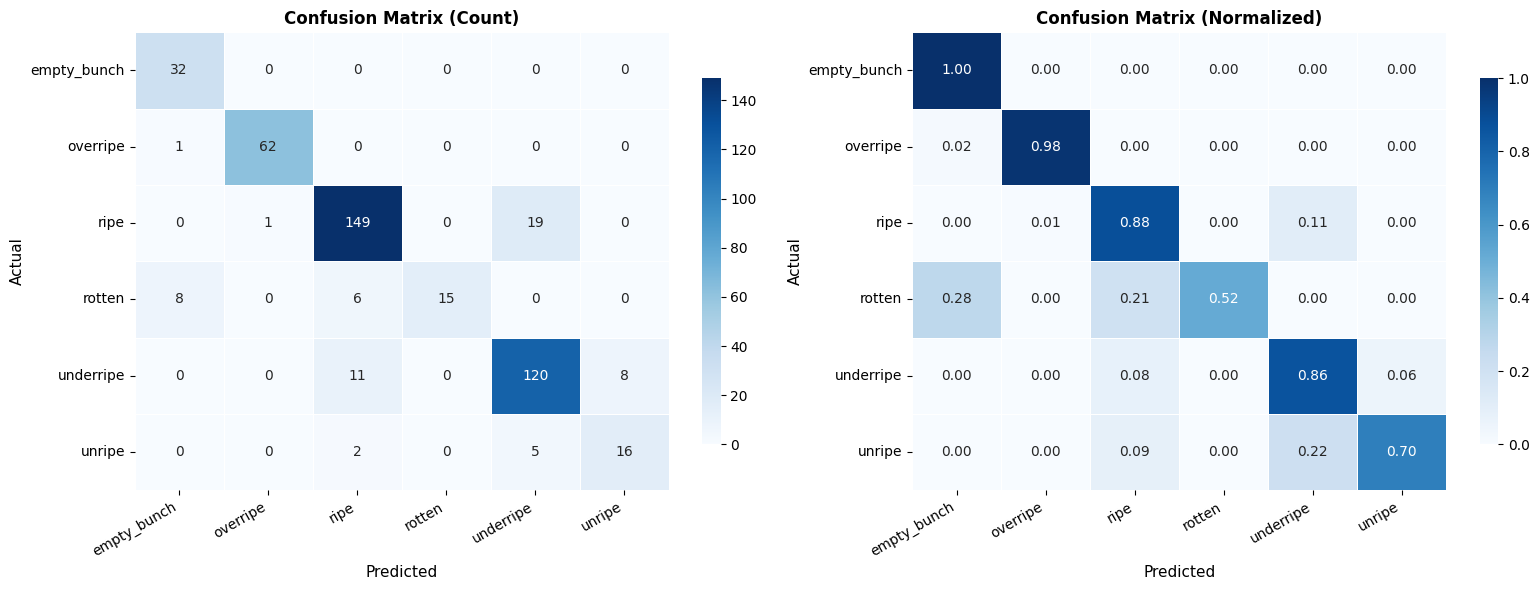

In [ ]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion Matrix (Count)', 'Confusion Matrix (Normalized)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
    ax.set_yticklabels(CLASS_NAMES, rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

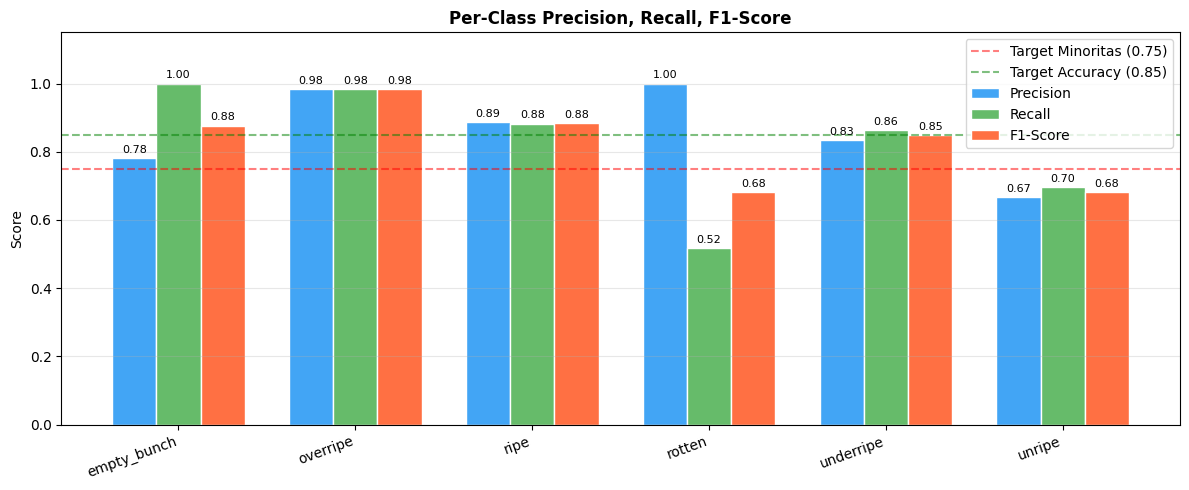

In [ ]:
# Per-Class Metrics Bar Chart
from sklearn.metrics import precision_score, recall_score

precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
recall    = recall_score(all_labels, all_preds, average=None, zero_division=0)
f1_per    = f1_score(all_labels, all_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(12, 5))
x   = np.arange(len(CLASS_NAMES))
w   = 0.25
ax.bar(x - w, precision, w, label='Precision', color='#42A5F5', edgecolor='white')
ax.bar(x,     recall,    w, label='Recall',    color='#66BB6A', edgecolor='white')
ax.bar(x + w, f1_per,    w, label='F1-Score',  color='#FF7043', edgecolor='white')

for i, (p, r, f) in enumerate(zip(precision, recall, f1_per)):
    for val, offset in [(p, -w), (r, 0), (f, w)]:
        ax.text(i + offset, val + 0.01, f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision, Recall, F1-Score', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Garis target
ax.axhline(0.75, color='red',   linestyle='--', alpha=0.5, label='Target Minoritas (0.75)')
ax.axhline(0.85, color='green', linestyle='--', alpha=0.5, label='Target Accuracy (0.85)')
ax.legend()
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## **9. Grad-CAM Visualization**

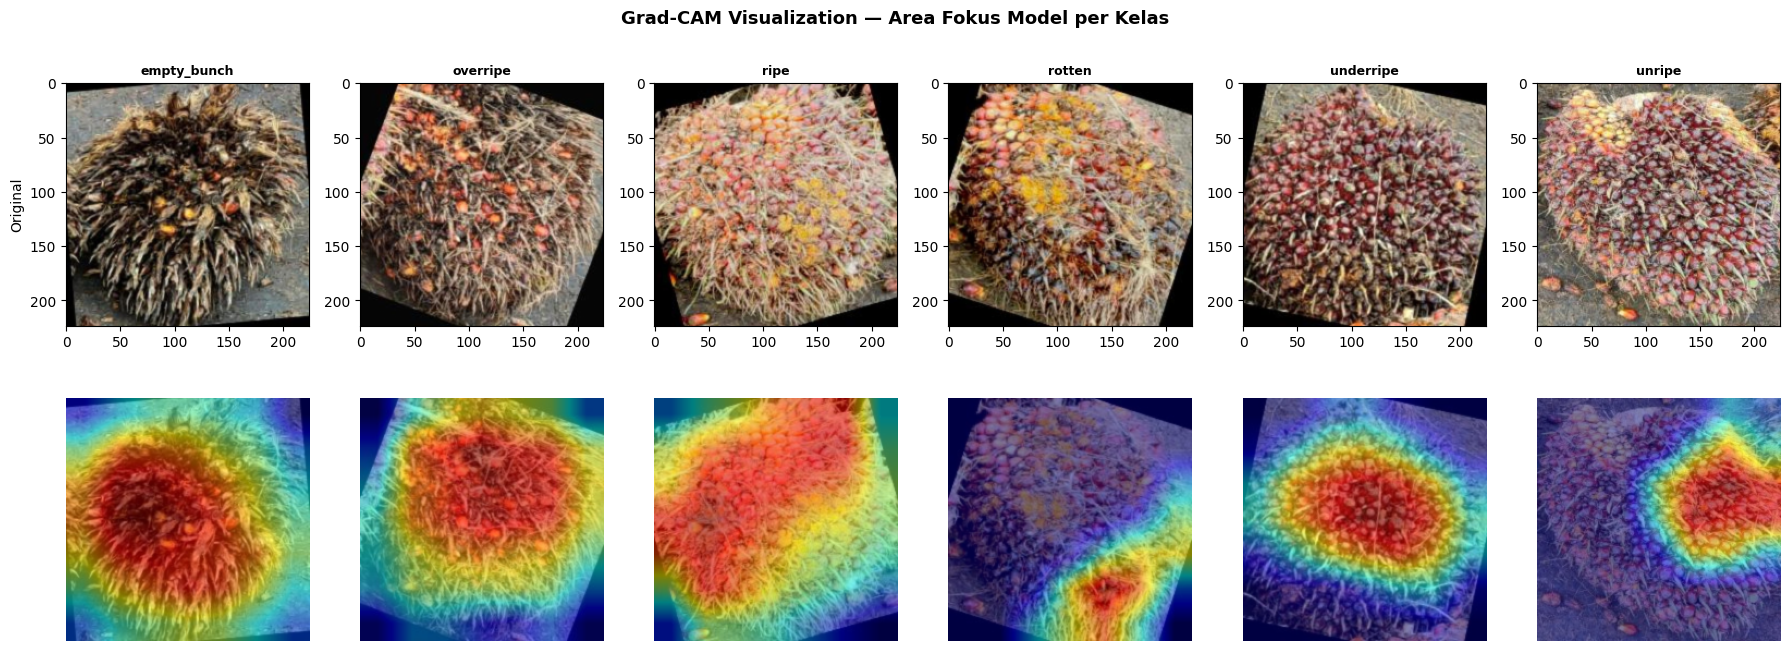

Grad-CAM visualization selesai ✓


In [ ]:
import sys
!{sys.executable} -m pip install grad-cam > /dev/null
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Target layer: last conv block of EfficientNetV2-S
# timm model: backbone.blocks[-1][-1]
target_layers = [model.backbone.blocks[-1][-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Ambil 1 contoh per kelas dari test set
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(18, 7))
fig.suptitle('Grad-CAM Visualization — Area Fokus Model per Kelas', fontsize=13, fontweight='bold')

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    # Cari sample dari test set
    sample_idx = next((i for i, (_, lbl) in enumerate(test_dataset.samples) if lbl == cls_idx), None)
    if sample_idx is None:
        continue

    img_tensor, _ = test_dataset[sample_idx]
    input_tensor  = img_tensor.unsqueeze(0).to(DEVICE)
    rgb_img       = denormalize(img_tensor).permute(1, 2, 0).numpy()

    targets       = [ClassifierOutputTarget(cls_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    cam_image     = show_cam_on_image(rgb_img, grayscale_cam[0], use_rgb=True)

    # Original
    axes[0, cls_idx].imshow(rgb_img)
    axes[0, cls_idx].set_title(cls_name, fontsize=9, fontweight='bold')
    axes[0, 0].set_ylabel('Original', fontsize=10)

    # Grad-CAM
    axes[1, cls_idx].imshow(cam_image)
    axes[1, cls_idx].axis('off')
    if cls_idx == 0:
        axes[1, 0].set_ylabel('Grad-CAM', fontsize=10)

plt.tight_layout()
plt.savefig('gradcam_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grad-CAM visualization selesai ✓')

## **10. SVM + Fitur Pretrained CNN (Hybrid)**
> Cara 2 — SVM + Fitur Pretrained CNN (Modern / Hybrid)
> Backbone EfficientNetV2-S digunakan sebagai **feature extractor** (tanpa dilatih ulang).  
> Fitur vektor yang dihasilkan backbone kemudian digunakan sebagai input SVM.  

```
Gambar → EfficientNetV2-S (frozen, feature extractor) → Vektor Fitur → SVM → Prediksi
```

In [ ]:
import numpy as np
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, cohen_kappa_score,
    precision_score, recall_score
)
import matplotlib.pyplot as plt
import seaborn as sns

print('Library untuk SVM baseline siap!')

Library untuk SVM baseline siap!


### **10.1 Ekstraksi Fitur Menggunakan EfficientNet V2-S (Frozen)**

In [ ]:
import timm
import torch
import torch.nn as nn

# Load backbone EfficientNetV2-S pretrained (tanpa head)
feature_extractor = timm.create_model(
    'tf_efficientnetv2_s.in21k',
    pretrained=True,
    num_classes=0,
    global_pool='avg'
)
feature_extractor = feature_extractor.to(DEVICE)
feature_extractor.eval()

# Bekukan semua parameter
for param in feature_extractor.parameters():
    param.requires_grad = False

print(f'Feature extractor siap!')
print(f'Output dimensi fitur: {feature_extractor.num_features}')

Feature extractor siap!
Output dimensi fitur: 1280


In [ ]:
def extract_features(loader, model, device, desc='Extracting'):

    all_features = []
    all_labels   = []

    model.eval()
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=desc):
            imgs = imgs.to(device)
            feats = model(imgs)
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    X = np.vstack(all_features)
    y = np.hstack(all_labels)
    return X, y

print('Mengekstrak fitur dari dataset...')
X_train, y_train = extract_features(train_loader, feature_extractor, DEVICE, 'Train')
X_val,   y_val   = extract_features(val_loader,   feature_extractor, DEVICE, 'Valid')
X_test,  y_test  = extract_features(test_loader,  feature_extractor, DEVICE, 'Test')

print(f'\nUkuran fitur:')
print(f'  Train : {X_train.shape}')
print(f'  Valid : {X_val.shape}')
print(f'  Test  : {X_test.shape}')

Mengekstrak fitur dari dataset...


Test: 100%|██████████| 15/15 [00:04<00:00,  3.61it/s]


Ukuran fitur:
  Train : (2099, 1280)
  Valid : (470, 1280)
  Test  : (455, 1280)


### **10.2 Training SVM Classifier**

In [ ]:
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.hstack([y_train, y_val])

print(f'Total data training SVM: {X_train_full.shape[0]} sampel')
print(f'Dimensi fitur           : {X_train_full.shape[1]}')

Total data training SVM: 2569 sampel
Dimensi fitur           : 1280


In [ ]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=10.0,
        gamma='scale',
        class_weight='balanced',
        random_state=SEED,
        probability=True
    ))
])

print('Training SVM...')
svm_pipeline.fit(X_train_full, y_train_full)
print('Training SVM selesai!')

Training SVM...
Training SVM selesai!


### **10.3 Evaluasi SVM**

In [ ]:
# Prediksi pada test set
y_pred_svm = svm_pipeline.predict(X_test)

# Hitung metrik
acc_svm      = accuracy_score(y_test, y_pred_svm)
macro_f1_svm = f1_score(y_test, y_pred_svm, average='macro',  zero_division=0)
micro_f1_svm = f1_score(y_test, y_pred_svm, average='micro',  zero_division=0)
kappa_svm    = cohen_kappa_score(y_test, y_pred_svm)

print('=' * 55)
print('HASIL EVALUASI SVM PADA TEST SET')
print('=' * 55)
print(f'  Accuracy       : {acc_svm:.4f}  ({acc_svm*100:.2f}%)')
print(f'  Macro F1-Score : {macro_f1_svm:.4f}')
print(f'  Micro F1-Score : {micro_f1_svm:.4f}')
print(f"  Cohen's Kappa  : {kappa_svm:.4f}")
print('=' * 55)

print('\nClassification Report SVM:')
print(classification_report(y_test, y_pred_svm,
                             target_names=CLASS_NAMES,
                             zero_division=0))

HASIL EVALUASI SVM PADA TEST SET
  Accuracy       : 0.6440  (64.40%)
  Macro F1-Score : 0.5233
  Micro F1-Score : 0.6440
  Cohen's Kappa  : 0.5025

Classification Report SVM:
              precision    recall  f1-score   support

 empty_bunch       0.63      0.75      0.69        32
    overripe       0.68      0.65      0.67        63
        ripe       0.66      0.73      0.70       169
      rotten       1.00      0.10      0.19        29
   underripe       0.61      0.70      0.65       139
      unripe       0.44      0.17      0.25        23

    accuracy                           0.64       455
   macro avg       0.67      0.52      0.52       455
weighted avg       0.66      0.64      0.62       455



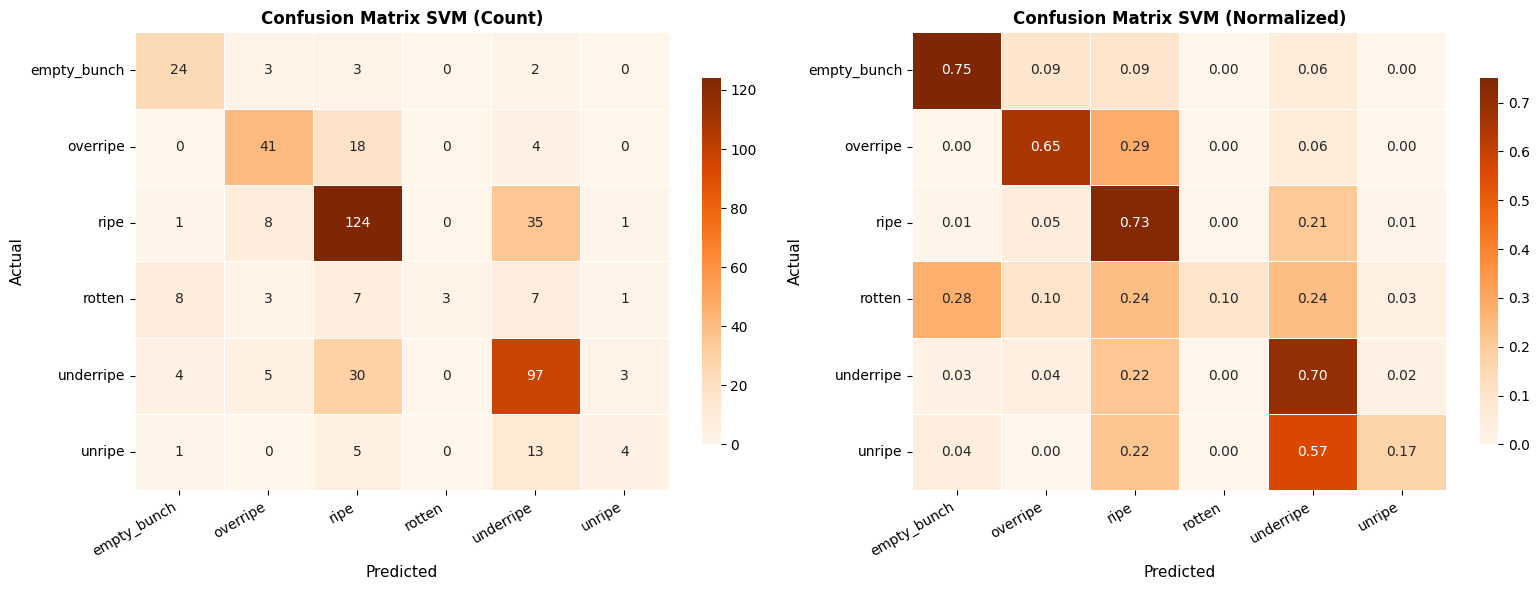

Confusion matrix SVM disimpan!


In [ ]:
# Confusion Matrix SVM
cm_svm      = confusion_matrix(y_test, y_pred_svm)
cm_svm_norm = cm_svm.astype(float) / cm_svm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, fmt, title in zip(
    axes,
    [cm_svm, cm_svm_norm],
    ['d', '.2f'],
    ['Confusion Matrix SVM (Count)', 'Confusion Matrix SVM (Normalized)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Oranges',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
    ax.set_yticklabels(CLASS_NAMES, rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix_svm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix SVM disimpan!')

### **10.4 Perbandingan EfficientNetV2-S vs SVM Baseline**

In [ ]:
acc_cnn      = accuracy_score(all_labels, all_preds)
macro_f1_cnn = f1_score(all_labels, all_preds, average='macro',  zero_division=0)
micro_f1_cnn = f1_score(all_labels, all_preds, average='micro',  zero_division=0)
kappa_cnn    = cohen_kappa_score(all_labels, all_preds)

# Tabel perbandingan
print('=' * 65)
print('PERBANDINGAN MODEL: EfficientNetV2-S vs SVM Baseline')
print('=' * 65)
print(f'{"Metrik":<20} {"EfficientNetV2-S":>20} {"SVM Baseline":>15}')
print('-' * 65)
print(f'{"Accuracy":<20} {acc_cnn:>19.4f} {acc_svm:>15.4f}')
print(f'{"Macro F1-Score":<20} {macro_f1_cnn:>19.4f} {macro_f1_svm:>15.4f}')
print(f'{"Micro F1-Score":<20} {micro_f1_cnn:>19.4f} {micro_f1_svm:>15.4f}')
print(f"{"Cohen's Kappa":<20} {kappa_cnn:>19.4f} {kappa_svm:>15.4f}")
print('=' * 65)

# Hitung selisih peningkatan
delta_acc = (acc_cnn - acc_svm) * 100
delta_f1  = (macro_f1_cnn - macro_f1_svm) * 100
print(f'\nPeningkatan EfficientNetV2-S vs SVM:')
print(f'  Accuracy       : +{delta_acc:.2f}%')
print(f'  Macro F1-Score : +{delta_f1:.2f}%')

PERBANDINGAN MODEL: EfficientNetV2-S vs SVM Baseline
Metrik                   EfficientNetV2-S    SVM Baseline
-----------------------------------------------------------------
Accuracy                          0.8659          0.6440
Macro F1-Score                    0.8260          0.5233
Micro F1-Score                    0.8659          0.6440
Cohen's Kappa                     0.8178          0.5025

Peningkatan EfficientNetV2-S vs SVM:
  Accuracy       : +22.20%
  Macro F1-Score : +30.27%


## **11. Ringkasan Hasil**

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Hitung per-class metrics SVM
precision_svm = precision_score(y_test, y_pred_svm, average=None, zero_division=0)
recall_svm    = recall_score(y_test, y_pred_svm, average=None, zero_division=0)
f1_per_svm    = f1_score(y_test, y_pred_svm, average=None, zero_division=0)

# Tabel 1: EfficientNetV2-S
summary_cnn = pd.DataFrame({
    'Kelas'    : CLASS_NAMES,
    'Precision': precision.round(4),
    'Recall'   : recall.round(4),
    'F1-Score' : f1_per.round(4),
    'Support'  : cm.sum(axis=1)
})

print('\n' + '='*55)
print('RINGKASAN HASIL PER KELAS — EfficientNetV2-S')
print('='*55)
print(summary_cnn.to_string(index=False))
print('-'*55)
print(f'{"Accuracy":<15}: {acc:.4f} ({acc*100:.2f}%)')
print(f'{"Macro F1":<15}: {macro_f1:.4f}')
print(f'{"Cohen Kappa":<15}: {kappa:.4f}')
print('='*55)

#  Tabel 2: SVM Baseline
summary_svm = pd.DataFrame({
    'Kelas'    : CLASS_NAMES,
    'Precision': precision_svm.round(4),
    'Recall'   : recall_svm.round(4),
    'F1-Score' : f1_per_svm.round(4),
    'Support'  : cm_svm.sum(axis=1)
})

print('\n' + '='*55)
print('RINGKASAN HASIL PER KELAS — SVM Baseline')
print('='*55)
print(summary_svm.to_string(index=False))
print('-'*55)
print(f'{"Accuracy":<15}: {acc_svm:.4f} ({acc_svm*100:.2f}%)')
print(f'{"Macro F1":<15}: {macro_f1_svm:.4f}')
print(f'{"Cohen Kappa":<15}: {kappa_svm:.4f}')
print('='*55)

#  Ringkasan metrik keseluruhan
print('\n' + '='*65)
print('RINGKASAN METRIK KESELURUHAN')
print('='*65)
print(f'{"Metrik":<20} {"EfficientNetV2-S":>20} {"SVM Baseline":>15}')
print('-'*65)
print(f'{"Accuracy":<20} {acc:>19.4f} {acc_svm:>15.4f}')
print(f'{"Macro F1-Score":<20} {macro_f1:>19.4f} {macro_f1_svm:>15.4f}')
print(f"{'Cohens Kappa':<20} {kappa:>19.4f} {kappa_svm:>15.4f}")
print('='*65)

#  Interpretasi Kappa
for label, k in [('EfficientNetV2-S', kappa), ('SVM Baseline', kappa_svm)]:
    interp = (
        'Hampir sempurna (>0.80)' if k > 0.80 else
        'Substansial (0.61-0.80)' if k > 0.60 else
        'Moderat (0.41-0.60)'     if k > 0.40 else
        'Cukup (0.21-0.40)'       if k > 0.20 else
        'Lemah (<0.20)'
    )
    print(f'  Kappa {label:<20}: {k:.4f} → {interp}')

#  Pengecekan target capaian
target_acc         = 0.85
target_f1_minority = 0.75
minority_classes   = ['rotten', 'unripe', 'empty_bunch']

print('\n' + '='*65)
print(f'✅ Model terbaik: EfficientNetV2-S')
print('='*65)


RINGKASAN HASIL PER KELAS — EfficientNetV2-S
      Kelas  Precision  Recall  F1-Score  Support
empty_bunch     0.7805  1.0000    0.8767       32
   overripe     0.9841  0.9841    0.9841       63
       ripe     0.8869  0.8817    0.8843      169
     rotten     1.0000  0.5172    0.6818       29
  underripe     0.8333  0.8633    0.8481      139
     unripe     0.6667  0.6957    0.6809       23
-------------------------------------------------------
Accuracy       : 0.8659 (86.59%)
Macro F1       : 0.8260
Cohen Kappa    : 0.8178

RINGKASAN HASIL PER KELAS — SVM Baseline
      Kelas  Precision  Recall  F1-Score  Support
empty_bunch     0.6316  0.7500    0.6857       32
   overripe     0.6833  0.6508    0.6667       63
       ripe     0.6631  0.7337    0.6966      169
     rotten     1.0000  0.1034    0.1875       29
  underripe     0.6139  0.6978    0.6532      139
     unripe     0.4444  0.1739    0.2500       23
-------------------------------------------------------
Accuracy       : 0.

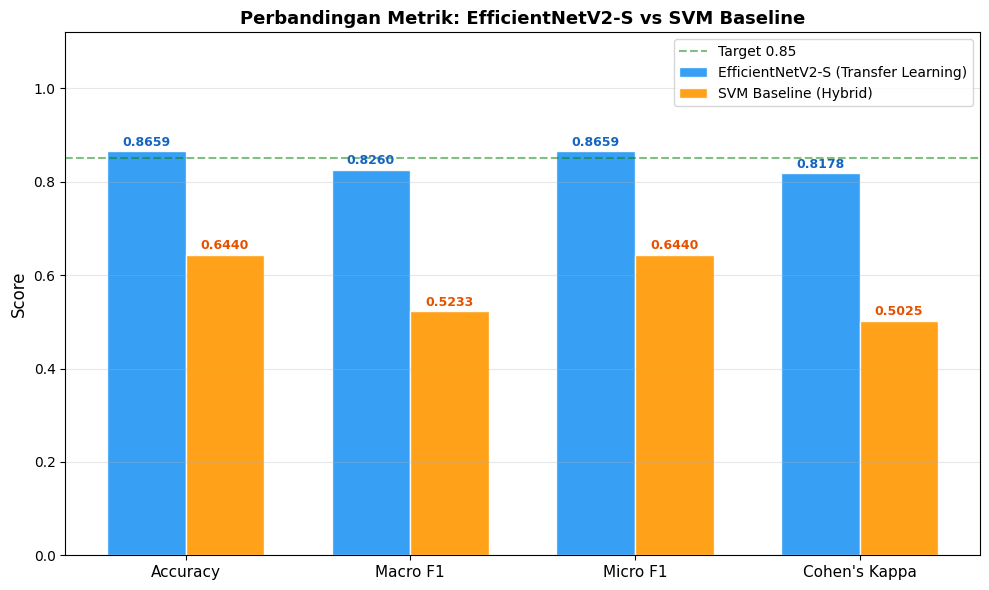

Grafik perbandingan disimpan!


In [ ]:
metrics_names = ['Accuracy', 'Macro F1', 'Micro F1', "Cohen's Kappa"]
cnn_scores    = [acc_cnn, macro_f1_cnn, micro_f1_cnn, kappa_cnn]
svm_scores    = [acc_svm, macro_f1_svm, micro_f1_svm, kappa_svm]

x     = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_cnn = ax.bar(x - width/2, cnn_scores, width,
                  label='EfficientNetV2-S (Transfer Learning)',
                  color='#2196F3', edgecolor='white', alpha=0.9)
bars_svm = ax.bar(x + width/2, svm_scores, width,
                  label='SVM Baseline (Hybrid)',
                  color='#FF9800', edgecolor='white', alpha=0.9)

for bar in bars_cnn:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#1565C0')

for bar in bars_svm:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#E65100')

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perbandingan Metrik: EfficientNetV2-S vs SVM Baseline',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.85, color='green', linestyle='--', alpha=0.5, label='Target 0.85')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('comparison_cnn_vs_svm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik perbandingan disimpan!')

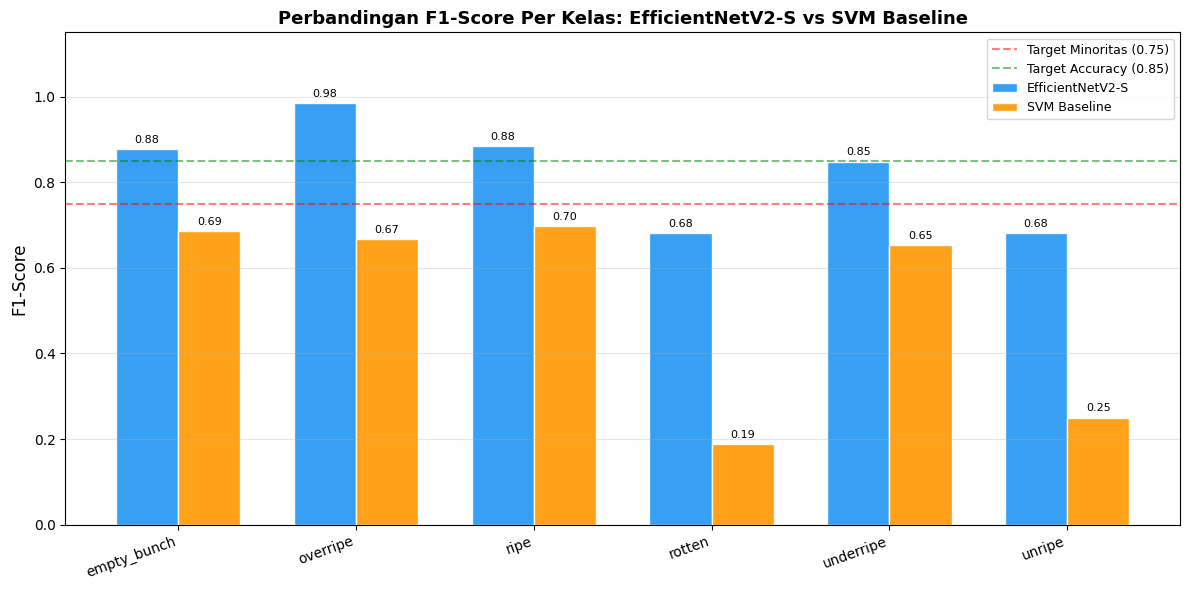

Grafik perbandingan F1 per kelas disimpan!


In [ ]:
# Perbandingan Per-Kelas: F1-Score CNN vs SVM
f1_cnn_per = f1_score(all_labels, all_preds, average=None, zero_division=0)
f1_svm_per = f1_score(y_test, y_pred_svm,   average=None, zero_division=0)

x     = np.arange(len(CLASS_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars_cnn = ax.bar(x - width/2, f1_cnn_per, width,
                  label='EfficientNetV2-S',
                  color='#2196F3', edgecolor='white', alpha=0.9)
bars_svm = ax.bar(x + width/2, f1_svm_per, width,
                  label='SVM Baseline',
                  color='#FF9800', edgecolor='white', alpha=0.9)

for bar in bars_cnn:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

for bar in bars_svm:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Perbandingan F1-Score Per Kelas: EfficientNetV2-S vs SVM Baseline',
             fontsize=13, fontweight='bold')
ax.axhline(0.75, color='red',   linestyle='--', alpha=0.5, label='Target Minoritas (0.75)')
ax.axhline(0.85, color='green', linestyle='--', alpha=0.5, label='Target Accuracy (0.85)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik perbandingan F1 per kelas disimpan!')

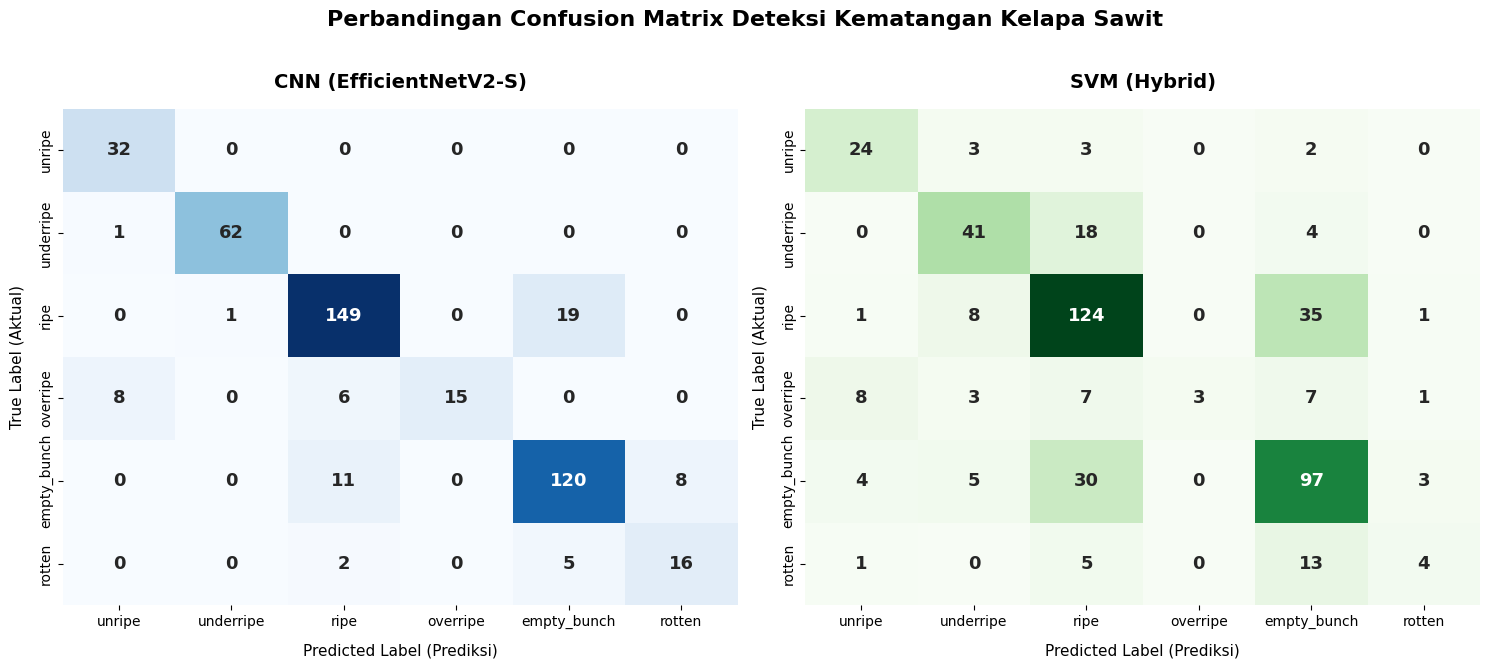

In [ ]:
# Perbandingan Confussion Matrix
cm_cnn = confusion_matrix(all_labels, all_preds)
cm_svm = confusion_matrix(y_test, y_pred_svm)

target_names = ['unripe', 'underripe', 'ripe', 'overripe', 'empty_bunch', 'rotten']

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names,
            cbar=False, annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title("CNN (EfficientNetV2-S)", fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel("Predicted Label (Prediksi)", fontsize=11, labelpad=10)
axes[0].set_ylabel("True Label (Aktual)", fontsize=11, labelpad=10)
axes[0].tick_params(labelsize=10)

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names,
            cbar=False, annot_kws={"size": 13, "weight": "bold"})
axes[1].set_title("SVM (Hybrid)", fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel("Predicted Label (Prediksi)", fontsize=11, labelpad=10)
axes[1].set_ylabel("True Label (Aktual)", fontsize=11, labelpad=10)
axes[1].tick_params(labelsize=10)

plt.suptitle("Perbandingan Confusion Matrix Deteksi Kematangan Kelapa Sawit",
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

In [ ]:
# Ringkasan Akhir
print('=' * 65)
print('RINGKASAN AKHIR PERBANDINGAN MODEL')
print('=' * 65)
print(f'\n📊 EfficientNetV2-S (Transfer Learning + Two-Phase Fine-Tuning):')
print(f'   Accuracy       : {acc_cnn:.4f} ({acc_cnn*100:.2f}%)')
print(f'   Macro F1-Score : {macro_f1_cnn:.4f}')
print(f"   Cohen's Kappa  : {kappa_cnn:.4f} (Almost Perfect)")

print(f'\n📊 SVM Baseline (Hybrid: Pretrained CNN Features + SVM):')
print(f'   Accuracy       : {acc_svm:.4f} ({acc_svm*100:.2f}%)')
print(f'   Macro F1-Score : {macro_f1_svm:.4f}')
print(f"   Cohen's Kappa  : {kappa_svm:.4f}")

print(f'\n🔺 Peningkatan EfficientNetV2-S terhadap SVM Baseline:')
print(f'   Accuracy       : +{(acc_cnn - acc_svm)*100:.2f}%')
print(f'   Macro F1-Score : +{(macro_f1_cnn - macro_f1_svm)*100:.2f}%')
print(f"   Cohen's Kappa  : +{(kappa_cnn - kappa_svm):.4f}")
print('=' * 65)

winner = 'EfficientNetV2-S' if acc_cnn > acc_svm else 'SVM Baseline'
print(f'\n✅ Model terbaik: {winner}')

RINGKASAN AKHIR PERBANDINGAN MODEL

📊 EfficientNetV2-S (Transfer Learning + Two-Phase Fine-Tuning):
   Accuracy       : 0.8659 (86.59%)
   Macro F1-Score : 0.8260
   Cohen's Kappa  : 0.8178 (Almost Perfect)

📊 SVM Baseline (Hybrid: Pretrained CNN Features + SVM):
   Accuracy       : 0.6440 (64.40%)
   Macro F1-Score : 0.5233
   Cohen's Kappa  : 0.5025

🔺 Peningkatan EfficientNetV2-S terhadap SVM Baseline:
   Accuracy       : +22.20%
   Macro F1-Score : +30.27%
   Cohen's Kappa  : +0.3153

✅ Model terbaik: EfficientNetV2-S


## ---

In [ ]:
# import ipywidgets as widgets
# from IPython.display import display
# !pip install grad-cam > /dev/null
# from pytorch_grad_cam import GradCAM
# from pytorch_grad_cam.utils.image import show_cam_on_image
# from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
# from torchvision import transforms
# from PIL import Image
# import numpy as np
# import matplotlib.pyplot as plt

# def plot_gradcam_interactive(img_path, true_class, pred_class):
#     # Load gambar
#     img_pil = Image.open(img_path).convert('RGB')

#     # Preprocessing
#     transform_vis = transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
#     ])

#     img_tensor = transform_vis(img_pil).unsqueeze(0).to(DEVICE)

#     # Denormalisasi untuk visualisasi
#     img_np = np.array(img_pil.resize((224, 224))).astype(np.float32) / 255.0

#     # Target layer backbone EfficientNetV2-S
#     target_layers = [model.backbone.conv_head]
#     cam = GradCAM(model=model, target_layers=target_layers)

#     # Generate Grad-CAM
#     targets = [ClassifierOutputTarget(CLASS_NAMES.index(pred_class))]
#     grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]
#     visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

#     # Plot
#     fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#     axes[0].imshow(img_pil.resize((224, 224)))
#     axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
#     axes[0].axis('off')

#     axes[1].imshow(visualization)
#     axes[1].set_title(f'Grad-CAM\nPrediksi: {pred_class}', fontsize=12, fontweight='bold')
#     axes[1].axis('off')

#     # Info label
#     color = 'green' if true_class == pred_class else 'red'
#     status = '✅ Benar' if true_class == pred_class else '❌ Salah'
#     fig.suptitle(
#         f'Label Asli: {true_class}  |  Prediksi: {pred_class}  |  {status}',
#         fontsize=12, fontweight='bold', color=color
#     )

#     plt.tight_layout()
#     plt.show()


# #  Kumpulkan sampel dari test set
# from pathlib import Path

# test_samples = []
# for cls in CLASS_NAMES:
#     cls_path = TEST_DIR / cls
#     imgs = list(cls_path.glob('*.[jp][pn]g')) + list(cls_path.glob('*.jpeg'))
#     for img_path in imgs:
#         test_samples.append((str(img_path), cls))

# print(f'Total sampel untuk visualisasi: {len(test_samples)}')


# #  Prediksi semua sampel untuk dropdown
# model.eval()
# sample_options = []

# transform_vis = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
# ])

# for img_path, true_label in test_samples:
#     img_pil    = Image.open(img_path).convert('RGB')
#     img_tensor = transform_vis(img_pil).unsqueeze(0).to(DEVICE)

#     with torch.no_grad():
#         logits = model(img_tensor)
#         pred   = CLASS_NAMES[logits.argmax(dim=1).item()]

#     status = '✅' if pred == true_label else '❌'
#     label  = f'{status} [{true_label}] → {pred} | {Path(img_path).stem[:30]}'
#     sample_options.append((label, (img_path, true_label, pred)))

In [ ]:
# #  Widget
# img_dropdown = widgets.Dropdown(
#     options=sample_options,
#     description='Pilih Gambar:',
#     style={'description_width': 'initial'},
#     layout=widgets.Layout(width='80%')
# )

# class_filter = widgets.RadioButtons(
#     options=['Semua Kelas'] + CLASS_NAMES,
#     description='Filter Kelas:',
#     style={'description_width': 'initial'},
#     layout=widgets.Layout(width='30%')
# )

# def update_dropdown(change):
#     selected_class = class_filter.value
#     if selected_class == 'Semua Kelas':
#         img_dropdown.options = sample_options
#     else:
#         filtered = [
#             (lbl, val) for lbl, val in sample_options
#             if val[1] == selected_class
#         ]
#         img_dropdown.options = filtered

# class_filter.observe(update_dropdown, names='value')

# def show_gradcam_interactive(sample):
#     img_path, true_class, pred_class = sample
#     plot_gradcam_interactive(img_path, true_class, pred_class)

# out = widgets.interactive_output(
#     show_gradcam_interactive,
#     {'sample': img_dropdown}
# )

# display(
#     widgets.VBox([
#         widgets.HTML('<h3>🌴 Interactive Grad-CAM Explorer</h3>'),
#         widgets.HBox([class_filter]),
#         img_dropdown,
#         out
#     ])
# )

In [ ]:
# !pip install lime
# import ipywidgets as widgets
# from IPython.display import display
# from lime import lime_image
# from skimage.segmentation import mark_boundaries
# from torchvision import transforms
# from PIL import Image
# import numpy as np
# import matplotlib.pyplot as plt
# from pathlib import Path

# def svm_predict_fn(images):
#     feats = []
#     for img in images:
#         img_pil = Image.fromarray((img * 255).astype(np.uint8)).convert('RGB')
#         img_tensor = transform_vis(img_pil).unsqueeze(0).to(DEVICE)
#         with torch.no_grad():
#             feat = feature_extractor(img_tensor).cpu().numpy().flatten()
#         feats.append(feat)
#     feats = np.array(feats)
#     return svm_pipeline.predict_proba(feats)

# def plot_lime_interactive(img_path, true_class, pred_class):
#     img_pil = Image.open(img_path).convert('RGB').resize((224, 224))
#     img_np  = np.array(img_pil).astype(np.float32) / 255.0

#     explainer = lime_image.LimeImageExplainer()

#     explanation = explainer.explain_instance(
#         img_np,
#         svm_predict_fn,
#         top_labels=NUM_CLASSES,
#         hide_color=0,
#         num_samples=500
#     )

#     pred_idx = explanation.top_labels[0]
#     temp, mask = explanation.get_image_and_mask(
#         pred_idx,
#         positive_only=True,
#         num_features=8,
#         hide_rest=False
#     )

#     # Plot
#     fig, axes = plt.subplots(1, 3, figsize=(13, 4))

#     axes[0].imshow(img_pil)
#     axes[0].set_title('Original Image', fontsize=11, fontweight='bold')
#     axes[0].axis('off')

#     axes[1].imshow(mark_boundaries(temp, mask))
#     axes[1].set_title('LIME — Area Positif\n(mendukung prediksi)', fontsize=11, fontweight='bold')
#     axes[1].axis('off')

#     temp_neg, mask_neg = explanation.get_image_and_mask(
#         pred_idx,
#         positive_only=False,
#         negative_only=True,
#         num_features=8,
#         hide_rest=False
#     )
#     axes[2].imshow(mark_boundaries(temp_neg, mask_neg, color=(1, 0, 0)))
#     axes[2].set_title('LIME — Area Negatif\n(melawan prediksi)', fontsize=11, fontweight='bold')
#     axes[2].axis('off')

#     color  = 'green' if true_class == pred_class else 'red'
#     status = '✅ Benar' if true_class == pred_class else '❌ Salah'
#     fig.suptitle(
#         f'Label Asli: {true_class}  |  Prediksi: {pred_class}  |  {status}',
#         fontsize=12, fontweight='bold', color=color
#     )

#     plt.tight_layout()
#     plt.show()


# # Transform
# transform_vis = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
# ])

# # Kumpulkan sampel dari test set
# test_samples = []
# for cls in CLASS_NAMES:
#     cls_path = TEST_DIR / cls
#     imgs = list(cls_path.glob('*.[jp][pn]g')) + list(cls_path.glob('*.jpeg'))
#     for img_path in imgs:
#         test_samples.append((str(img_path), cls))

# print(f'Total sampel untuk visualisasi: {len(test_samples)}')

# # Prediksi semua sampel dengan SVM
# sample_options = []

# for img_path, true_label in test_samples:
#     img_pil    = Image.open(img_path).convert('RGB')
#     img_tensor = transform_vis(img_pil).unsqueeze(0).to(DEVICE)

#     with torch.no_grad():
#         feat = feature_extractor(img_tensor).cpu().numpy().flatten()

#     pred = CLASS_NAMES[svm_pipeline.predict([feat])[0]]

#     status = '✅' if pred == true_label else '❌'
#     label  = f'{status} [{true_label}] → {pred} | {Path(img_path).stem[:30]}'
#     sample_options.append((label, (img_path, true_label, pred)))

In [ ]:
# # Widget
# img_dropdown = widgets.Dropdown(
#     options=sample_options,
#     description='Pilih Gambar:',
#     style={'description_width': 'initial'},
#     layout=widgets.Layout(width='80%')
# )

# class_filter = widgets.RadioButtons(
#     options=['Semua Kelas'] + CLASS_NAMES,
#     description='Filter Kelas:',
#     style={'description_width': 'initial'},
#     layout=widgets.Layout(width='30%')
# )

# def update_dropdown(change):
#     selected_class = class_filter.value
#     if selected_class == 'Semua Kelas':
#         img_dropdown.options = sample_options
#     else:
#         filtered = [
#             (lbl, val) for lbl, val in sample_options
#             if val[1] == selected_class
#         ]
#         img_dropdown.options = filtered

# class_filter.observe(update_dropdown, names='value')

# def show_lime_interactive(sample):
#     img_path, true_class, pred_class = sample
#     plot_lime_interactive(img_path, true_class, pred_class)

# out = widgets.interactive_output(
#     show_lime_interactive,
#     {'sample': img_dropdown}
# )

# display(
#     widgets.VBox([
#         widgets.HTML('<h3>🌴 Interactive LIME Explorer — SVM Baseline</h3>'),
#         widgets.HBox([class_filter]),
#         img_dropdown,
#         out
#     ])
# )

## Validasi

In [ ]:
# VALIDASI 1 DATA LEAKAGE CHECK
from pathlib import Path

train_files = {
    Path(x[0]).name.lower()
    for x in train_dataset.samples
}

val_files = {
    Path(x[0]).name.lower()
    for x in val_dataset.samples
}

test_files = {
    Path(x[0]).name.lower()
    for x in test_dataset.samples
}

train_val_overlap = train_files & val_files
train_test_overlap = train_files & test_files
val_test_overlap = val_files & test_files

print("="*50)
print("LEAKAGE CHECK")
print("="*50)

print(f"Train-Val overlap  : {len(train_val_overlap)}")
print(f"Train-Test overlap : {len(train_test_overlap)}")
print(f"Val-Test overlap   : {len(val_test_overlap)}")

if (
    len(train_val_overlap)==0 and
    len(train_test_overlap)==0 and
    len(val_test_overlap)==0
):
    print("\n✓ Tidak ada indikasi leakage")
else:
    print("\n⚠ Ada kemungkinan leakage")

LEAKAGE CHECK
Train-Val overlap  : 0
Train-Test overlap : 0
Val-Test overlap   : 0

✓ Tidak ada indikasi leakage


In [ ]:
# VALIDASI 2 — OVERFITTING CHECK
train_acc_final = history_p2['train_acc'][-1]
val_acc_final   = history_p2['val_acc'][-1]

gap = train_acc_final - val_acc_final

print("="*50)
print("OVERFITTING CHECK")
print("="*50)

print(f"Train Accuracy : {train_acc_final:.4f}")
print(f"Val Accuracy   : {val_acc_final:.4f}")
print(f"Gap            : {gap:.4f}")

if gap < 0.05:
    print("\n✓ Overfitting rendah")
elif gap < 0.10:
    print("\n⚠ Overfitting ringan")
else:
    print("\n⚠ Overfitting sedang/tinggi")

OVERFITTING CHECK
Train Accuracy : 0.9995
Val Accuracy   : 0.8340
Gap            : 0.1655

⚠ Overfitting sedang/tinggi


In [ ]:
# VALIDASI 3 — PER CLASS ANALYSIS
report = classification_report(
    all_labels,
    all_preds,
    target_names=CLASS_NAMES,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

display(
    df_report[
        ['precision','recall','f1-score','support']
    ].round(4)
)

worst_class = df_report.iloc[:-3]['f1-score'].idxmin()

print("\nKelas dengan performa terendah:")
print(worst_class)
print(
    df_report.loc[
        worst_class,
        ['precision','recall','f1-score']
    ]
)

,precision,recall,f1-score,support
empty_bunch,0.7805,1.0000,0.8767,32.0000
overripe,0.9841,0.9841,0.9841,63.0000
ripe,0.8869,0.8817,0.8843,169.0000
rotten,1.0000,0.5172,0.6818,29.0000
underripe,0.8333,0.8633,0.8481,139.0000
unripe,0.6667,0.6957,0.6809,23.0000
accuracy,0.8659,0.8659,0.8659,0.8659
macro avg,0.8586,0.8237,0.8260,455.0000
weighted avg,0.8726,0.8659,0.8633,455.0000



Kelas dengan performa terendah:
unripe
precision    0.666667
recall       0.695652
f1-score     0.680851
Name: unripe, dtype: float64


Jumlah prediksi salah: 61


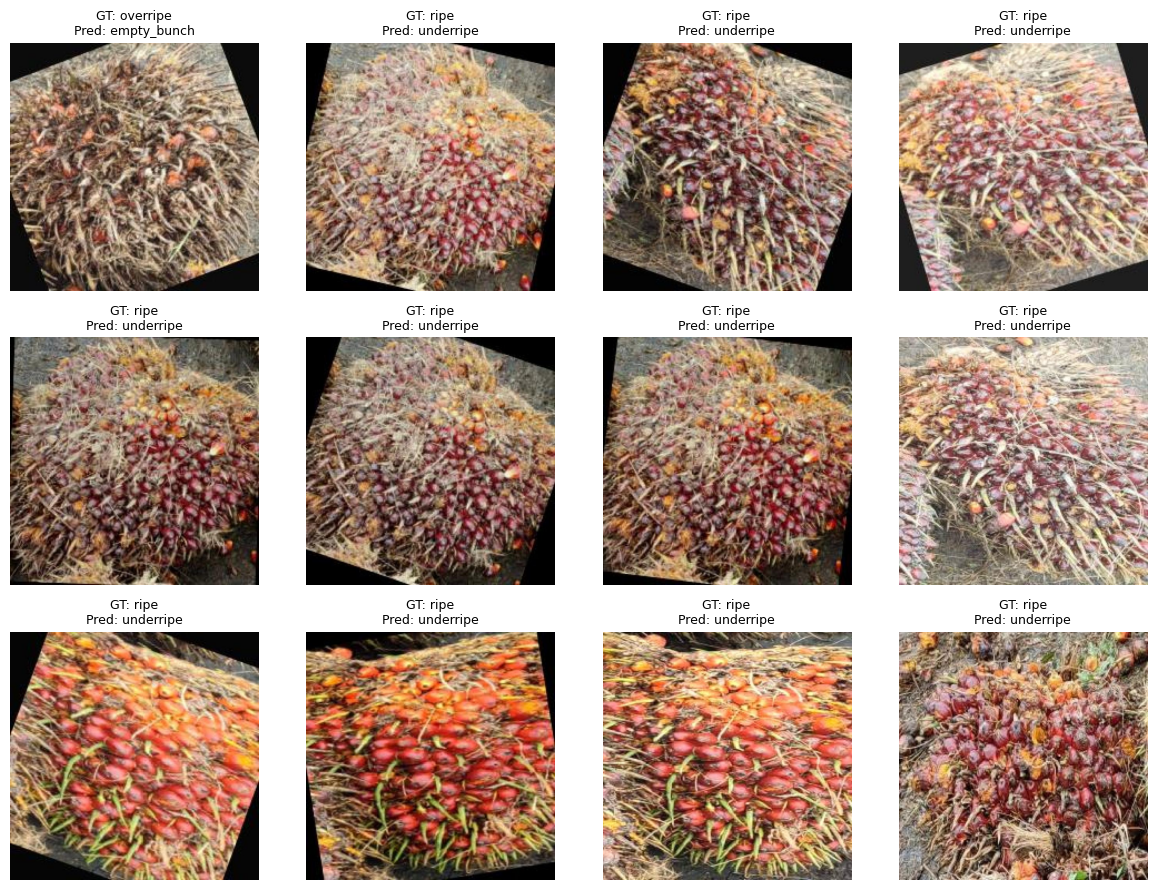

In [ ]:
# VALIDASI 4 — ERROR ANALYSIS
wrong_idx = np.where(
    np.array(all_preds) != np.array(all_labels)
)[0]

print(
    f"Jumlah prediksi salah: {len(wrong_idx)}"
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(12,9)
)

axes = axes.flatten()

for ax, idx in zip(
    axes,
    wrong_idx[:12]
):

    img_path, true_label = test_dataset.samples[idx]

    img = Image.open(
        img_path
    ).convert("RGB")

    pred_label = all_preds[idx]

    ax.imshow(img)

    ax.set_title(
        f"GT: {CLASS_NAMES[true_label]}\n"
        f"Pred: {CLASS_NAMES[pred_label]}",
        fontsize=9
    )

    ax.axis("off")

plt.tight_layout()
plt.show()